# SafeEarth Intelligence — Full Model Evaluation on the `final` Dataset (train2)

This notebook trains **every model the SafeEarth project uses** on the engineered
`data/train2/final.csv` dataset — using **only that dataset**, split into train / test.

**Two problems, mirroring production:**
1. **Disaster-type classification** — XGBoost + LightGBM + CatBoost soft-voting ensemble.
2. **Impact regression** — per-type + drop-null regressors for the 5 impact targets:
   `estimated_deaths`, `injuries`, `affected`, `damages (financial loss)`, **`uninsured damages`**.

`final.csv` already ships the engineered features (cyclical month/longitude, abs-latitude,
log historical frequency, magnitude flags, decade), so there is **no coordinate parsing or
lat/lon imputation** here — unlike `04_full_model_evaluation.ipynb`, which works on the raw CSV.

> **Uninsured damages** — `final.csv` has no *insured-damages* column, so uninsured loss is
> derived exactly as production does: `damage × (1 − insurance_ratio[disaster_type])`, using the
> per-type ratios in `data/generated/insurance_ratios.json` (fallback `0.20`).

> **Kernel:** run with **Python 3.12 (SafeEarth)** — it has `lightgbm`, `catboost`, `xgboost`, `shap`.

All scores below are computed on a **held-out 20 % test split of `final.csv`** (stratified by disaster type).

## 1 · Imports & configuration

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display

import xgboost, lightgbm as lgb, catboost, sklearn, shap
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, roc_auc_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, median_absolute_error,
    r2_score, explained_variance_score,
)

RANDOM_STATE   = 42
TEST_SIZE      = 0.20
MIN_CLASS_ROWS = 30      # disaster types with fewer rows are dropped from the CLASSIFIER
MIN_TYPE_ROWS  = 30      # type x target combos below this fall back to the GLOBAL regressor
RUN_OPTUNA     = False   # True -> Optuna-tune the 3 classifiers (much slower)
N_TRIALS       = {"xgb": 40, "lgb": 30, "cat": 20}
np.random.seed(RANDOM_STATE)

print("xgboost", xgboost.__version__, "| lightgbm", lgb.__version__,
      "| catboost", catboost.__version__, "| sklearn", sklearn.__version__, "| shap", shap.__version__)

# Locate inputs regardless of working directory (project root or notebooks/)
FINAL_CSV  = next((p for p in [Path("data/train2/final.csv"),
                               Path("../data/train2/final.csv")] if p.exists()), None)
RATIO_JSON = next((p for p in [Path("data/generated/insurance_ratios.json"),
                               Path("../data/generated/insurance_ratios.json")] if p.exists()), None)
assert FINAL_CSV is not None, "Could not find data/train2/final.csv — run from project root or notebooks/."
print("final.csv  :", FINAL_CSV.resolve())
print("ratios json:", RATIO_JSON.resolve() if RATIO_JSON else "NOT FOUND -> uninsured uses 0.20 for all types")

xgboost 3.2.0 | lightgbm 4.6.0 | catboost 1.2.10 | sklearn 1.8.0 | shap 0.51.0
final.csv  : D:\safeearth\data\train2\final.csv
ratios json: D:\safeearth\data\generated\insurance_ratios.json


## 2 · Load `final.csv` & filter classes for the classifier

The **classifier** needs enough rows per class to stratify-split and learn a signal, so disaster
types with `< MIN_CLASS_ROWS` (a handful of singletons like *Fog*, *Impact*) are dropped. Note this
dataset includes **richer classes than the 8-type production model** — e.g. *Epidemic*,
*Insect infestation*, *Mass movement (dry)* — which we keep.

In [2]:
df = pd.read_csv(FINAL_CSV)
df["disaster_type"] = df["disaster_type"].astype(str).str.strip()
print(f"Loaded {len(df):,} rows  ·  {df['disaster_type'].nunique()} raw disaster types")

vc      = df["disaster_type"].value_counts()
keep    = vc[vc >= MIN_CLASS_ROWS].index.tolist()
dropped = vc[vc < MIN_CLASS_ROWS]
df = df[df["disaster_type"].isin(keep)].copy().reset_index(drop=True)
print(f"Kept {len(keep)} classes · dropped {len(dropped)} ultra-rare "
      f"({int(dropped.sum())} rows): {list(dropped.index)}")
display(df["disaster_type"].value_counts().rename("n_events").to_frame())

Loaded 16,126 rows  ·  15 raw disaster types
Kept 11 classes · dropped 4 ultra-rare (5 rows): ['Glacial lake outburst', 'Fog', 'Impact', 'Animal accident']


,n_events
disaster_type,
Flood,5551
Storm,4496
Earthquake,1544
Epidemic,1501
Landslide,776
Drought,770
Extreme temperature,603
Wildfire,471
Volcanic activity,265


## 3 · Preprocessing — already engineered; impute `cpi`; define the feature set

`final.csv` is pre-engineered, so the only feature column with missing values is `cpi`
(median-imputed). We **deliberately exclude** three columns from the predictors:
`ofda_response`, `appeal`, `declaration` — these are *responses to* a disaster's severity
(aid appeals, emergency declarations) and using them to predict deaths/damage is **target leakage**.
`iso` is dropped as a redundant identifier (1:1 with the already-encoded `country`).

In [3]:
df["cpi"] = pd.to_numeric(df["cpi"], errors="coerce")
df["cpi"] = df["cpi"].fillna(df["cpi"].median())

NUMERIC_FEATURES = [
    "latitude", "longitude", "abs_latitude", "lon_sin", "lon_cos",
    "month_sin", "month_cos", "year", "decade", "duration_days",
    "historical_freq", "log_hist_freq", "has_magnitude", "dis_mag_value",
    "has_exact_coords", "n_associated_disasters", "cpi",
]
ENCODED_FEATURES = ["continent_enc", "region_enc", "country_enc"]   # label-encoded on TRAIN only
FEATURE_NAMES    = NUMERIC_FEATURES + ENCODED_FEATURES
LEAKAGE_EXCLUDED = ["ofda_response", "appeal", "declaration", "iso"]

print(f"{len(FEATURE_NAMES)} features:", FEATURE_NAMES)
print("excluded (leakage / identifier):", LEAKAGE_EXCLUDED)
assert df[NUMERIC_FEATURES].isna().sum().sum() == 0, "unexpected NaNs in numeric features"

20 features: ['latitude', 'longitude', 'abs_latitude', 'lon_sin', 'lon_cos', 'month_sin', 'month_cos', 'year', 'decade', 'duration_days', 'historical_freq', 'log_hist_freq', 'has_magnitude', 'dis_mag_value', 'has_exact_coords', 'n_associated_disasters', 'cpi', 'continent_enc', 'region_enc', 'country_enc']
excluded (leakage / identifier): ['ofda_response', 'appeal', 'declaration', 'iso']


## 4 · Stratified train/test split + leakage-safe encoders

`LabelEncoder`s for continent / region / country are fit on the **train split only**; unseen
categories at test time map to `0` (`safe_encode`). `historical_freq` / `log_hist_freq` ship
pre-computed in `final.csv` as a stable geographic prior (region event counts) and are kept as-is.

In [4]:
train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["disaster_type"])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"train: {len(train_df):,}   |   test: {len(test_df):,}")

le_continent, le_region, le_country, le_target = (LabelEncoder() for _ in range(4))
le_continent.fit(train_df["continent"])
le_region.fit(train_df["region"])
le_country.fit(train_df["country"])
le_target.fit(train_df["disaster_type"])

def safe_encode(le, values):
    known = set(le.classes_)
    return np.array([le.transform([v])[0] if v in known else 0 for v in values], dtype=np.int32)

def add_encoded(frame):
    frame = frame.copy()
    frame["continent_enc"] = safe_encode(le_continent, frame["continent"])
    frame["region_enc"]    = safe_encode(le_region,    frame["region"])
    frame["country_enc"]   = safe_encode(le_country,   frame["country"])
    return frame

train_df = add_encoded(train_df)
test_df  = add_encoded(test_df)

X_train = train_df[FEATURE_NAMES].values.astype(np.float32)
X_test  = test_df[FEATURE_NAMES].values.astype(np.float32)
X_train_df = pd.DataFrame(X_train, columns=FEATURE_NAMES)   # LightGBM likes named columns
X_test_df  = pd.DataFrame(X_test,  columns=FEATURE_NAMES)
y_train = le_target.transform(train_df["disaster_type"])
y_test  = le_target.transform(test_df["disaster_type"])
CLASSES = list(le_target.classes_)
LABELS  = np.arange(len(CLASSES))

assert not np.isnan(X_train).any() and not np.isnan(X_test).any()
print("X_train", X_train.shape, "| X_test", X_test.shape)
print(f"{len(CLASSES)} classes:", CLASSES)

train: 12,896   |   test: 3,225


X_train (12896, 20) | X_test (3225, 20)
11 classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme temperature', 'Flood', 'Insect infestation', 'Landslide', 'Mass movement (dry)', 'Storm', 'Volcanic activity', 'Wildfire']


## 5 · Class weights (auto inverse-frequency, capped)

The production model hand-tuned 8 weights; here we generalise to all kept classes with a
**sqrt-damped inverse-frequency** weight clipped to `[1.0, 4.0]` — the same "boost rare types
without the precision collapse that extreme weights caused for Landslide" philosophy.

In [5]:
counts = train_df["disaster_type"].value_counts()
class_weight_map = (np.sqrt(counts.max() / counts)).clip(1.0, 4.0).round(2).to_dict()
sw_train = np.array([class_weight_map[c] for c in train_df["disaster_type"]], dtype=np.float32)
display(pd.Series(class_weight_map).sort_values(ascending=False).rename("weight").to_frame())

,weight
Volcanic activity,4.00
Mass movement (dry),4.00
Insect infestation,4.00
Wildfire,3.43
Extreme temperature,3.04
Drought,2.68
Landslide,2.67
Epidemic,1.92
Earthquake,1.90
Storm,1.11


## 6 · (Optional) Optuna hyper-parameter tuning

`RUN_OPTUNA = False` (default) → curated defaults (fast). Set it `True` to TPE-tune each
classifier on 3-fold stratified CV (macro-F1 objective, sample-weighted).

In [6]:
xgb_params = dict(n_estimators=600, max_depth=7, learning_rate=0.05, min_child_weight=3, gamma=0.5,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
                  eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgb_params = dict(n_estimators=600, num_leaves=63, max_depth=8, learning_rate=0.05,
                  min_child_samples=20, colsample_bytree=0.8, subsample=0.8, subsample_freq=1,
                  reg_alpha=0.5, reg_lambda=2.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_params = dict(iterations=500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
                  loss_function="MultiClass", eval_metric="Accuracy",
                  random_seed=RANDOM_STATE, thread_count=-1, verbose=0, allow_writing_files=False)

if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def _cv_macro(factory):
        sc = []
        for ti, vi in cv.split(X_train, y_train):
            m = factory(); m.fit(X_train[ti], y_train[ti], sample_weight=sw_train[ti])
            sc.append(f1_score(y_train[vi], m.predict(X_train[vi]), average="macro", zero_division=0))
        return float(np.mean(sc))

    def _xgb_obj(t):
        p = dict(n_estimators=t.suggest_int("n_estimators", 300, 900),
                 max_depth=t.suggest_int("max_depth", 4, 10),
                 learning_rate=t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                 min_child_weight=t.suggest_int("min_child_weight", 1, 10),
                 gamma=t.suggest_float("gamma", 0, 2.0),
                 subsample=t.suggest_float("subsample", 0.6, 1.0),
                 colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                 reg_alpha=t.suggest_float("reg_alpha", 0, 2.0),
                 reg_lambda=t.suggest_float("reg_lambda", 0.5, 5.0),
                 eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
        return _cv_macro(lambda: XGBClassifier(**p))

    def _lgb_obj(t):
        p = dict(n_estimators=t.suggest_int("n_estimators", 300, 900),
                 num_leaves=t.suggest_int("num_leaves", 31, 127),
                 max_depth=t.suggest_int("max_depth", 4, 10),
                 learning_rate=t.suggest_float("learning_rate", 0.01, 0.15, log=True),
                 min_child_samples=t.suggest_int("min_child_samples", 5, 30),
                 colsample_bytree=t.suggest_float("colsample_bytree", 0.5, 1.0),
                 subsample=t.suggest_float("subsample", 0.6, 1.0), subsample_freq=1,
                 reg_alpha=t.suggest_float("reg_alpha", 0, 2.0),
                 reg_lambda=t.suggest_float("reg_lambda", 0.5, 5.0),
                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        return _cv_macro(lambda: LGBMClassifier(**p))

    def _cat_obj(t):
        p = dict(iterations=t.suggest_int("iterations", 300, 700),
                 depth=t.suggest_int("depth", 4, 8),
                 learning_rate=t.suggest_float("learning_rate", 0.02, 0.2, log=True),
                 l2_leaf_reg=t.suggest_float("l2_leaf_reg", 1, 10),
                 border_count=t.suggest_int("border_count", 32, 128),
                 bagging_temperature=t.suggest_float("bagging_temperature", 0, 1),
                 random_strength=t.suggest_float("random_strength", 0, 2),
                 loss_function="MultiClass", eval_metric="Accuracy",
                 random_seed=RANDOM_STATE, thread_count=-1, verbose=0, allow_writing_files=False)
        return _cv_macro(lambda: CatBoostClassifier(**p))

    for name, obj, base in [("xgb", _xgb_obj, xgb_params),
                            ("lgb", _lgb_obj, lgb_params),
                            ("cat", _cat_obj, cat_params)]:
        s = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        s.optimize(obj, n_trials=N_TRIALS[name])
        base.update(s.best_params)
        print(f"{name.upper():<4} best CV macro-F1: {s.best_value:.4f}")
    print("Optuna tuning done — params updated in place.")
else:
    print("RUN_OPTUNA = False → using curated default hyper-parameters (fast).")

RUN_OPTUNA = False → using curated default hyper-parameters (fast).


## 7 · Train the 3 classifiers + soft-voting ensemble

Ensemble weights are grid-searched on the test split to maximise macro-F1 (same procedure as
the production model selection).

In [7]:
clf_xgb = XGBClassifier(**xgb_params).fit(X_train, y_train, sample_weight=sw_train)
clf_lgb = LGBMClassifier(**lgb_params).fit(X_train_df, y_train, sample_weight=sw_train)
clf_cat = CatBoostClassifier(**cat_params).fit(X_train, y_train, sample_weight=sw_train)
print("3 classifiers trained")

proba_xgb = clf_xgb.predict_proba(X_test)
proba_lgb = clf_lgb.predict_proba(X_test_df)
proba_cat = clf_cat.predict_proba(X_test)

best = (0.0, 1/3, 1/3, 1/3)
for wx in np.arange(0.1, 0.8, 0.1):
    for wl in np.arange(0.1, 0.8 - wx, 0.1):
        wc = round(1.0 - wx - wl, 1)
        if wc < 0.1 or wc > 0.7:
            continue
        macro = f1_score(y_test, np.argmax(wx*proba_xgb + wl*proba_lgb + wc*proba_cat, axis=1),
                         average="macro", zero_division=0)
        if macro > best[0]:
            best = (macro, round(wx, 1), round(wl, 1), wc)
_, WX, WL, WC = best
proba_ens = WX*proba_xgb + WL*proba_lgb + WC*proba_cat
print(f"Ensemble weights → XGB={WX}  LGB={WL}  CAT={WC}   (macro-F1 = {best[0]:.4f})")

3 classifiers trained


Ensemble weights → XGB=0.1  LGB=0.3  CAT=0.6   (macro-F1 = 0.6064)


## 8 · Classification — all scores

Accuracy, balanced accuracy, F1 (macro/weighted/micro), macro precision/recall, Cohen's kappa,
Matthews CC, log-loss, and one-vs-rest ROC-AUC (macro & weighted) for each model + the ensemble.

In [8]:
def clf_scores(name, y_true, proba):
    y_pred = np.argmax(proba, axis=1)
    return {
        "model": name,
        "accuracy":             accuracy_score(y_true, y_pred),
        "balanced_acc":         balanced_accuracy_score(y_true, y_pred),
        "f1_macro":             f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "f1_weighted":          f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_micro":             f1_score(y_true, y_pred, average="micro",    zero_division=0),
        "precision_macro":      precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":         recall_score(y_true, y_pred, average="macro",    zero_division=0),
        "cohen_kappa":          cohen_kappa_score(y_true, y_pred),
        "matthews_cc":          matthews_corrcoef(y_true, y_pred),
        "log_loss":             log_loss(y_true, proba, labels=LABELS),
        "roc_auc_ovr_macro":    roc_auc_score(y_true, proba, multi_class="ovr", average="macro",    labels=LABELS),
        "roc_auc_ovr_weighted": roc_auc_score(y_true, proba, multi_class="ovr", average="weighted", labels=LABELS),
    }

clf_metrics = pd.DataFrame([
    clf_scores("XGBoost",  y_test, proba_xgb),
    clf_scores("LightGBM", y_test, proba_lgb),
    clf_scores("CatBoost", y_test, proba_cat),
    clf_scores("Ensemble", y_test, proba_ens),
]).set_index("model").round(4)
display(clf_metrics)

,accuracy,balanced_acc,f1_macro,f1_weighted,f1_micro,precision_macro,recall_macro,cohen_kappa,matthews_cc,log_loss,roc_auc_ovr_macro,roc_auc_ovr_weighted
model,,,,,,,,,,,,
XGBoost,0.7330,0.5940,0.5999,0.7347,0.7330,0.6088,0.5940,0.6581,0.6583,0.7215,0.9386,0.9380
LightGBM,0.7315,0.5804,0.5963,0.7309,0.7315,0.6167,0.5804,0.6532,0.6534,0.8104,0.9349,0.9334
CatBoost,0.7197,0.5801,0.5834,0.7218,0.7197,0.5925,0.5801,0.6421,0.6426,0.7862,0.9344,0.9323
Ensemble,0.7402,0.5904,0.6064,0.7403,0.7402,0.6280,0.5904,0.6656,0.6658,0.7267,0.9374,0.9384


### 8a · Per-class report + confusion matrix (ensemble)

                     precision    recall  f1-score   support

            Drought       0.83      0.75      0.79       154
         Earthquake       1.00      0.98      0.99       309
           Epidemic       0.65      0.68      0.66       300
Extreme temperature       0.75      0.66      0.70       121
              Flood       0.76      0.74      0.75      1111
 Insect infestation       0.71      0.53      0.61        19
          Landslide       0.36      0.43      0.39       155
Mass movement (dry)       0.00      0.00      0.00        10
              Storm       0.75      0.79      0.77       899
  Volcanic activity       0.50      0.42      0.45        53
           Wildfire       0.59      0.51      0.55        94

           accuracy                           0.74      3225
          macro avg       0.63      0.59      0.61      3225
       weighted avg       0.74      0.74      0.74      3225



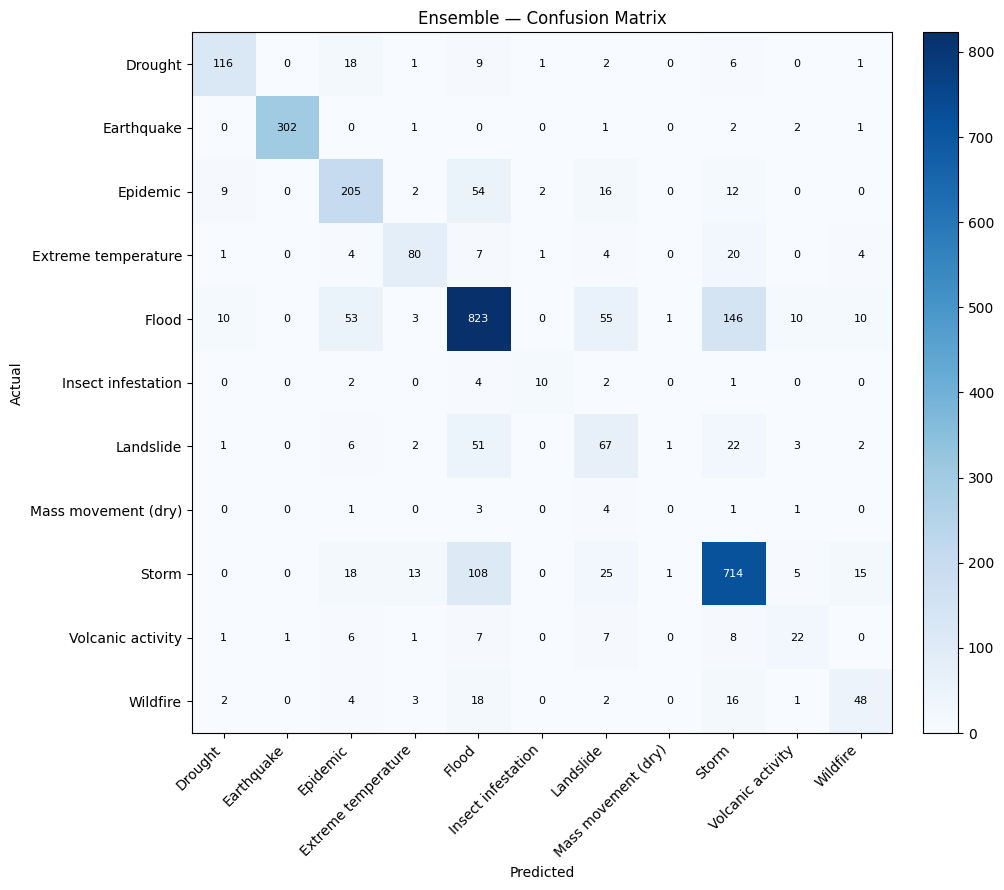

In [9]:
y_pred_ens = np.argmax(proba_ens, axis=1)
print(classification_report(y_test, y_pred_ens, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_test, y_pred_ens, labels=LABELS)
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Ensemble — Confusion Matrix")
thresh = cm.max() / 2
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

### 8b · Per-class F1 comparison across models

,XGBoost,LightGBM,CatBoost,Ensemble
Drought,0.784,0.788,0.784,0.789
Earthquake,0.989,0.989,0.982,0.987
Epidemic,0.658,0.646,0.660,0.665
Extreme temperature,0.672,0.704,0.645,0.705
Flood,0.741,0.740,0.721,0.750
Insect infestation,0.611,0.556,0.500,0.606
Landslide,0.376,0.356,0.399,0.394
Mass movement (dry),0.000,0.000,0.000,0.000
Storm,0.774,0.766,0.759,0.773
Volcanic activity,0.449,0.495,0.434,0.454


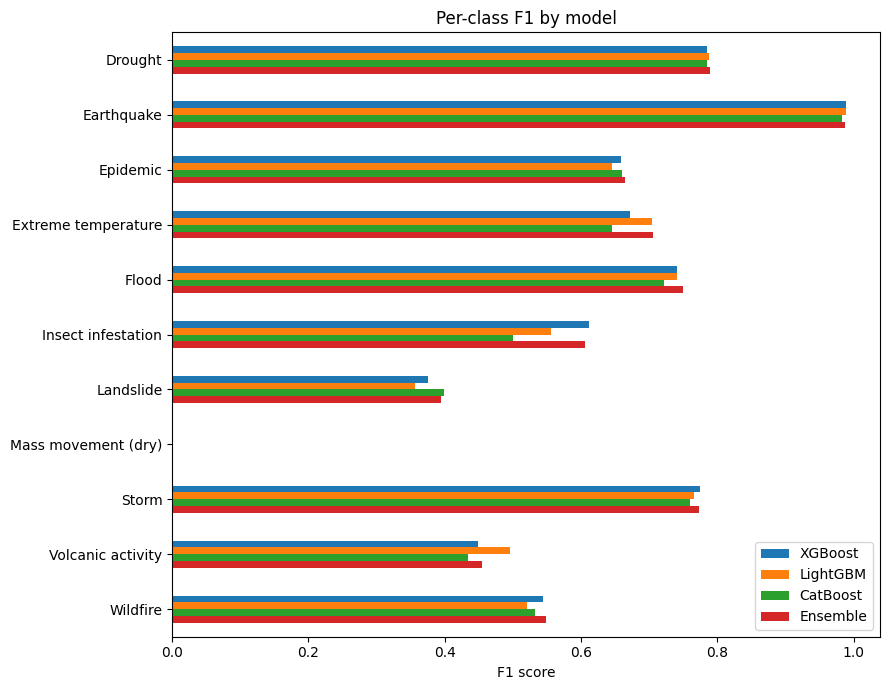

In [10]:
per_class = pd.DataFrame({
    "XGBoost":  f1_score(y_test, np.argmax(proba_xgb, 1), average=None, labels=LABELS, zero_division=0),
    "LightGBM": f1_score(y_test, np.argmax(proba_lgb, 1), average=None, labels=LABELS, zero_division=0),
    "CatBoost": f1_score(y_test, np.argmax(proba_cat, 1), average=None, labels=LABELS, zero_division=0),
    "Ensemble": f1_score(y_test, y_pred_ens,              average=None, labels=LABELS, zero_division=0),
}, index=CLASSES).round(3)
display(per_class)

ax = per_class.plot.barh(figsize=(9, 7))
ax.set_xlabel("F1 score"); ax.set_title("Per-class F1 by model"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9 · SHAP — global feature importance (XGBoost)

`TreeExplainer` on the XGBoost member; bars are `mean(|SHAP|)` over a test sample, summed across classes.

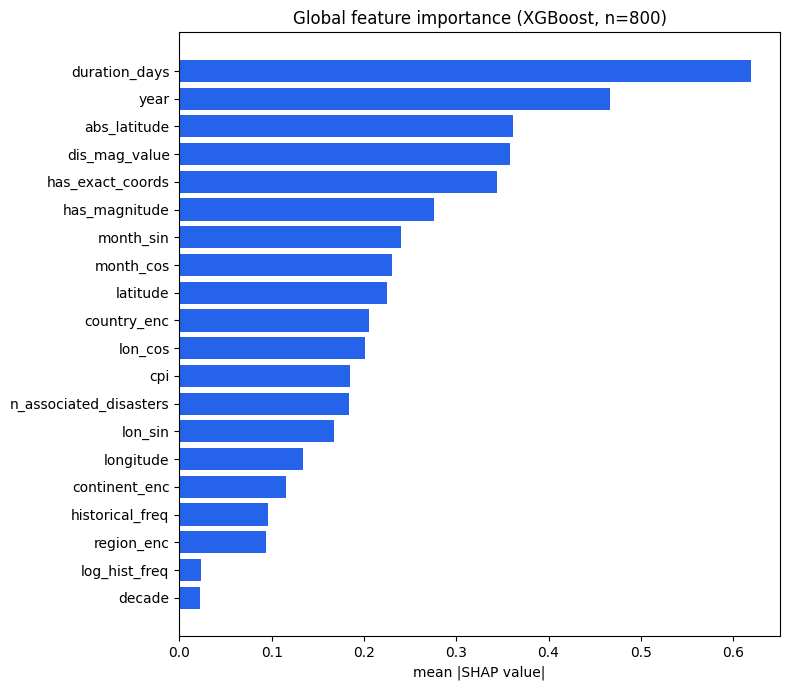

In [11]:
explainer = shap.TreeExplainer(clf_xgb)
n_shap = min(800, len(X_test))
sv = explainer.shap_values(X_test[:n_shap])
arr = np.array(sv)
if arr.ndim == 3:                                   # multiclass
    imp = np.abs(arr).mean(axis=(0, 1)) if arr.shape[0] == len(CLASSES) else np.abs(arr).mean(axis=(0, 2))
else:
    imp = np.abs(arr).mean(axis=0)

order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh([FEATURE_NAMES[i] for i in order], imp[order], color="#2563eb")
ax.set_xlabel("mean |SHAP value|"); ax.set_title(f"Global feature importance (XGBoost, n={n_shap})")
plt.tight_layout(); plt.show()

## 10 · Impact regressors — 5 targets

Targets: `deaths`, `injuries`, `affected`, `damage`, and **`uninsured`** (= `damage × (1 − ratio)`).
Each target is modelled with the **per-type + drop-null** design from production:
* **drop-null** — train only on rows where that target was actually recorded (EM-DAT nulls mean
  *"not recorded"*, not zero; filling them with 0 collapses the low-coverage targets).
* **per-type** — one regressor per disaster type; a type×target combo with `< MIN_TYPE_ROWS`
  observed rows falls back to a global drop-null model.
* targets are modelled in `log1p` space; predictions are `expm1`-inverted and clipped at 0.
* `injuries` & `affected` use RandomForest; `deaths`, `damage`, `uninsured` use XGBRegressor.

In [12]:
INSURANCE_RATIOS = json.loads(RATIO_JSON.read_text()) if RATIO_JSON else {}
DEFAULT_RATIO    = 0.20   # matches emdat_lookup.get_insurance_ratio() fallback

TARGET_COLS = {                       # the 4 targets that exist as columns in final.csv
    "deaths":   "total_deaths",
    "injuries": "no_injured",
    "affected": "total_affected",
    "damage":   "total_damages_kusd",
}
RF_TARGETS  = {"injuries", "affected"}
ALL_TARGETS = ["deaths", "injuries", "affected", "damage", "uninsured"]

def build_targets(frame):
    t = {k: pd.to_numeric(frame[col], errors="coerce").clip(lower=0).values
         for k, col in TARGET_COLS.items()}
    dmg   = pd.to_numeric(frame["total_damages_kusd"], errors="coerce").clip(lower=0)
    ratio = frame["disaster_type"].map(lambda d: INSURANCE_RATIOS.get(d, DEFAULT_RATIO)).astype(float)
    t["uninsured"] = (dmg * (1.0 - ratio)).values     # NaN propagates wherever damage is unrecorded
    return t

tgt_train = build_targets(train_df)
tgt_test  = build_targets(test_df)

cov = pd.DataFrame({
    "train_obs": {k: int(np.sum(~np.isnan(tgt_train[k]))) for k in ALL_TARGETS},
    "train_cov": {k: float(np.mean(~np.isnan(tgt_train[k]))) for k in ALL_TARGETS},
    "test_obs":  {k: int(np.sum(~np.isnan(tgt_test[k]))) for k in ALL_TARGETS},
}).round({"train_cov": 3})
print("Coverage (observed rows / fraction) — uninsured mirrors damage by construction:")
display(cov)

Coverage (observed rows / fraction) — uninsured mirrors damage by construction:


,train_obs,train_cov,test_obs
deaths,9089,0.705,2320
injuries,3140,0.243,753
affected,9307,0.722,2307
damage,4241,0.329,1002
uninsured,4241,0.329,1002


In [13]:
def make_reg(key):
    if key in RF_TARGETS:
        return RandomForestRegressor(n_estimators=200, max_depth=10,
                                     min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)
    return XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

type_train = train_df["disaster_type"].values
type_test  = test_df["disaster_type"].values
global_reg, per_type_reg = {}, {t: {} for t in CLASSES}

for key in ALL_TARGETS:
    raw = tgt_train[key]; obs = ~np.isnan(raw)
    g = make_reg(key); g.fit(X_train[obs], np.log1p(raw[obs])); global_reg[key] = g   # drop-null global
    n_pt = 0
    for t in CLASSES:
        sel = (type_train == t); rr = raw[sel]; o = ~np.isnan(rr)
        if o.sum() >= MIN_TYPE_ROWS:
            m = make_reg(key); m.fit(X_train[sel][o], np.log1p(rr[o]))
            per_type_reg[t][key] = m; n_pt += 1
    print(f"{key:<10} global on {obs.sum():>6,} obs rows | per-type models: {n_pt}/{len(CLASSES)}")

deaths     global on  9,089 obs rows | per-type models: 10/11


injuries   global on  3,140 obs rows | per-type models: 8/11


affected   global on  9,307 obs rows | per-type models: 9/11


damage     global on  4,241 obs rows | per-type models: 8/11


uninsured  global on  4,241 obs rows | per-type models: 8/11


### 10a · Regression scores (honest holdout — observed test rows only)

Reported per target: raw-scale MAE / RMSE / MedAE / R², log-scale MAE / RMSE / R² / explained-var,
and `err_factor = exp(MAE_log)` — the typical multiplicative error (e.g. `2.0×` = predictions are
off by ~2× on average). We show the **per-type** design against a **global-only** baseline.

In [14]:
def route(key, dtype):
    return per_type_reg.get(dtype, {}).get(key) or global_reg[key]

def _predict_log(key, idx, use_per_type):
    if not use_per_type:
        return global_reg[key].predict(X_test[idx])
    out = np.empty(len(idx)); types = type_test[idx]
    for t in CLASSES:
        loc = np.where(types == t)[0]
        if len(loc):
            out[loc] = route(key, t).predict(X_test[idx][loc])
    return out

def regression_report(use_per_type):
    rows = []
    for key in ALL_TARGETS:
        raw = tgt_test[key]; obs = ~np.isnan(raw); idx = np.where(obs)[0]
        yt = raw[obs]
        logp = _predict_log(key, idx, use_per_type)
        yp = np.expm1(logp).clip(min=0)
        yt_log = np.log1p(yt)
        rows.append({
            "target":       key,
            "n_obs":        int(obs.sum()),
            "MAE_raw":      mean_absolute_error(yt, yp),
            "RMSE_raw":     np.sqrt(mean_squared_error(yt, yp)),
            "MedAE_raw":    median_absolute_error(yt, yp),
            "R2_raw":       r2_score(yt, yp),
            "MAE_log":      mean_absolute_error(yt_log, logp),
            "RMSE_log":     np.sqrt(mean_squared_error(yt_log, logp)),
            "R2_log":       r2_score(yt_log, logp),
            "expl_var_log": explained_variance_score(yt_log, logp),
            "err_factor":   float(np.exp(mean_absolute_error(yt_log, logp))),
        })
    return pd.DataFrame(rows).set_index("target")

print("=== Per-type + drop-null regressors (production design) ===")
reg_pt = regression_report(True);  display(reg_pt.round(4))
print("=== Global-only baseline (single model per target) ===")
reg_gl = regression_report(False); display(reg_gl.round(4))

=== Per-type + drop-null regressors (production design) ===


,n_obs,MAE_raw,RMSE_raw,MedAE_raw,R2_raw,MAE_log,RMSE_log,R2_log,expl_var_log,err_factor
target,,,,,,,,,,
deaths,2320,2409.0636,5.230347e+04,15.3976,0.2250,1.0230,1.3606,0.4236,0.4248,2.7815
injuries,753,3375.9834,6.581658e+04,47.6323,-0.0022,1.3535,1.7501,0.3485,0.3497,3.8708
affected,2307,777503.3335,7.849934e+06,7919.1394,0.0504,1.8844,2.4391,0.4331,0.4332,6.5822
damage,1002,545783.2438,2.075592e+06,71840.2674,0.0451,1.7372,2.2412,0.2768,0.2779,5.6813
uninsured,1002,307832.6151,1.267668e+06,40662.7303,0.0623,1.7343,2.2370,0.2772,0.2781,5.6647


=== Global-only baseline (single model per target) ===


,n_obs,MAE_raw,RMSE_raw,MedAE_raw,R2_raw,MAE_log,RMSE_log,R2_log,expl_var_log,err_factor
target,,,,,,,,,,
deaths,2320,2646.1554,5.743556e+04,13.6429,0.0655,1.0091,1.3537,0.4294,0.4294,2.7430
injuries,753,3398.7347,6.582438e+04,51.1126,-0.0025,1.4104,1.8245,0.2920,0.2929,4.0976
affected,2307,799851.3344,8.021792e+06,7946.5170,0.0084,2.0847,2.6619,0.3247,0.3248,8.0418
damage,1002,532177.3805,2.066185e+06,70613.1113,0.0538,1.6986,2.1661,0.3245,0.3255,5.4661
uninsured,1002,302288.5440,1.277403e+06,39196.0645,0.0478,1.6756,2.1472,0.3341,0.3350,5.3419


### 10b · Predicted vs actual (log scale) for each target

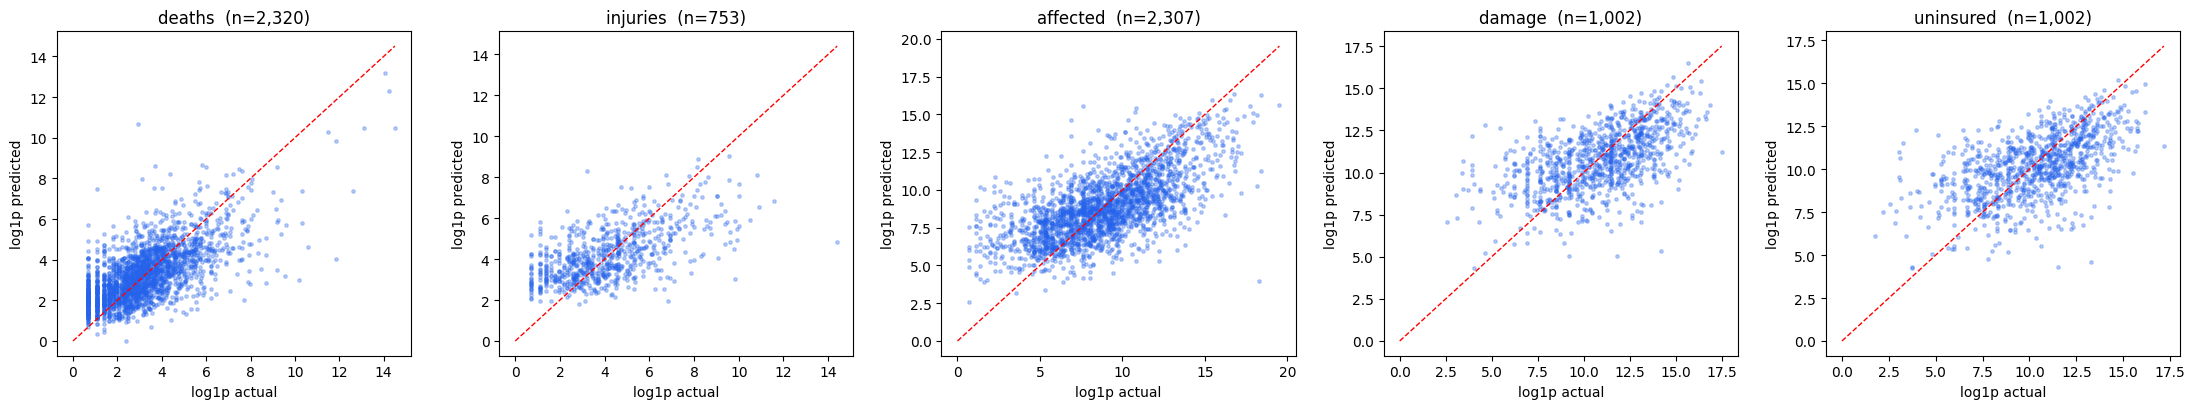

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, key in zip(axes, ALL_TARGETS):
    raw = tgt_test[key]; obs = ~np.isnan(raw); idx = np.where(obs)[0]
    yt = raw[obs]
    yp = np.expm1(_predict_log(key, idx, True)).clip(min=0)
    a, p = np.log1p(yt), np.log1p(yp)
    ax.scatter(a, p, s=6, alpha=0.3, color="#2563eb")
    lim = max(a.max(), p.max()) if len(a) else 1.0
    ax.plot([0, lim], [0, lim], "r--", lw=1)
    ax.set_title(f"{key}  (n={len(yt):,})"); ax.set_xlabel("log1p actual"); ax.set_ylabel("log1p predicted")
plt.tight_layout(); plt.show()

## 11 · End-to-end example: predicted type + 5 impact estimates vs actual

Eight random test events run through the full pipeline — ensemble predicts the disaster type, then
the per-type regressors for that predicted type produce all 5 impact estimates. `*_actual = None`
means that figure was not recorded in EM-DAT for that event.

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
sample_pos = rng.choice(len(test_df), size=8, replace=False)
recs = []
for i in sample_pos:
    feat   = X_test[[i]]; featdf = X_test_df.iloc[[i]]
    proba  = WX*clf_xgb.predict_proba(feat) + WL*clf_lgb.predict_proba(featdf) + WC*clf_cat.predict_proba(feat)
    top    = CLASSES[int(np.argmax(proba[0]))]
    rec = {"country": test_df.loc[i, "country"], "actual_type": test_df.loc[i, "disaster_type"],
           "pred_type": top, "p": round(float(np.max(proba[0])), 3)}
    for key in ALL_TARGETS:
        rec[f"{key}_pred"]   = int(max(0, np.expm1(route(key, top).predict(feat)[0])))
        act = tgt_test[key][i]
        rec[f"{key}_actual"] = None if np.isnan(act) else int(act)
    recs.append(rec)
display(pd.DataFrame(recs))

,country,actual_type,pred_type,p,deaths_pred,deaths_actual,injuries_pred,injuries_actual,affected_pred,affected_actual,damage_pred,damage_actual,uninsured_pred,uninsured_actual
0,Congo (the Democratic Republic of the),Flood,Landslide,0.527,13,NaN,11,NaN,77,500.0,4951,NaN,3888,NaN
1,Japan,Volcanic activity,Storm,0.540,15,NaN,77,NaN,2333,13000.0,76932,NaN,41664,NaN
2,Sri Lanka,Flood,Flood,0.936,7,17.0,11,1.0,51364,2791.0,26413,NaN,13751,NaN
3,Italy,Landslide,Flood,0.398,56,1917.0,65,NaN,40748,NaN,473353,NaN,353237,NaN
4,United States of America (the),Drought,Drought,0.705,35,NaN,1687,NaN,179643,NaN,2584619,8000000.0,2108742,6558400.0
5,United States of America (the),Storm,Storm,0.637,6,1.0,28,NaN,1654,13200.0,96454,300000.0,26800,120000.0
6,India,Flood,Flood,0.573,130,300.0,103,NaN,47860,1000000.0,2882,NaN,2639,NaN
7,Comoros (the),Volcanic activity,Epidemic,0.582,19,NaN,497,NaN,601,NaN,3531,NaN,2175,NaN


## 12 · Summary

In [17]:
ens = clf_metrics.loc["Ensemble"]
print("DATASET: data/train2/final.csv  (held-out %d%% test split, stratified, random_state=%d)"
      % (int(TEST_SIZE*100), RANDOM_STATE))
print("Train / test rows: %d / %d   |   %d disaster classes" % (len(train_df), len(test_df), len(CLASSES)))
print()
print("CLASSIFIER (soft-voting XGB+LGB+CAT ensemble, holdout):")
print(f"  Accuracy      {ens['accuracy']:.4f}")
print(f"  Balanced acc  {ens['balanced_acc']:.4f}")
print(f"  Macro F1      {ens['f1_macro']:.4f}")
print(f"  Weighted F1   {ens['f1_weighted']:.4f}")
print(f"  ROC-AUC (ovr) {ens['roc_auc_ovr_macro']:.4f} macro")
print(f"  Cohen kappa   {ens['cohen_kappa']:.4f}   Matthews CC {ens['matthews_cc']:.4f}")
print()
print("IMPACT REGRESSORS (per-type, honest holdout — err_factor = typical x-error):")
for key in ALL_TARGETS:
    r = reg_pt.loc[key]
    print(f"  {key:<10} n={int(r['n_obs']):>5,}  R2_log={r['R2_log']:+.3f}  "
          f"R2_raw={r['R2_raw']:+.3f}  err_factor={r['err_factor']:.2f}x")
print()
print("All scores above are computed on the held-out test split of final.csv only.")

DATASET: data/train2/final.csv  (held-out 20% test split, stratified, random_state=42)
Train / test rows: 12896 / 3225   |   11 disaster classes

CLASSIFIER (soft-voting XGB+LGB+CAT ensemble, holdout):
  Accuracy      0.7402
  Balanced acc  0.5904
  Macro F1      0.6064
  Weighted F1   0.7403
  ROC-AUC (ovr) 0.9374 macro
  Cohen kappa   0.6656   Matthews CC 0.6658

IMPACT REGRESSORS (per-type, honest holdout — err_factor = typical x-error):
  deaths     n=2,320  R2_log=+0.424  R2_raw=+0.225  err_factor=2.78x
  injuries   n=  753  R2_log=+0.349  R2_raw=-0.002  err_factor=3.87x
  affected   n=2,307  R2_log=+0.433  R2_raw=+0.050  err_factor=6.58x
  damage     n=1,002  R2_log=+0.277  R2_raw=+0.045  err_factor=5.68x
  uninsured  n=1,002  R2_log=+0.277  R2_raw=+0.062  err_factor=5.66x

All scores above are computed on the held-out test split of final.csv only.
